In [25]:
import numpy as np 
import pandas as pd
pd.set_option('display.max_columns',None)

In [26]:
train_data = pd.read_csv('train.csv')
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [27]:
#separating the categorical features and numerical features
num_cols = list(set(train_data.describe().columns.to_list()) - set(['Id']))
cat_cols = list(set(train_data.columns.to_list()) - set(num_cols) - set(['Id']))

In [28]:
len(num_cols)

37

array([[<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'EnclosedPorch'}>],
       [<Axes: title={'center': 'YrSold'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'GarageCars'}>,
        <Axes: title={'center': 'HalfBath'}>],
       [<Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotRmsAbvGrd'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>],
       [<Axes: title={'center': '3SsnPorch'}>,
        <Axes: title={'center': 'Fireplaces'}>,
        <Axes: title={'center': 'WoodDeckSF'}>, <Axes: >]], dtype=object)

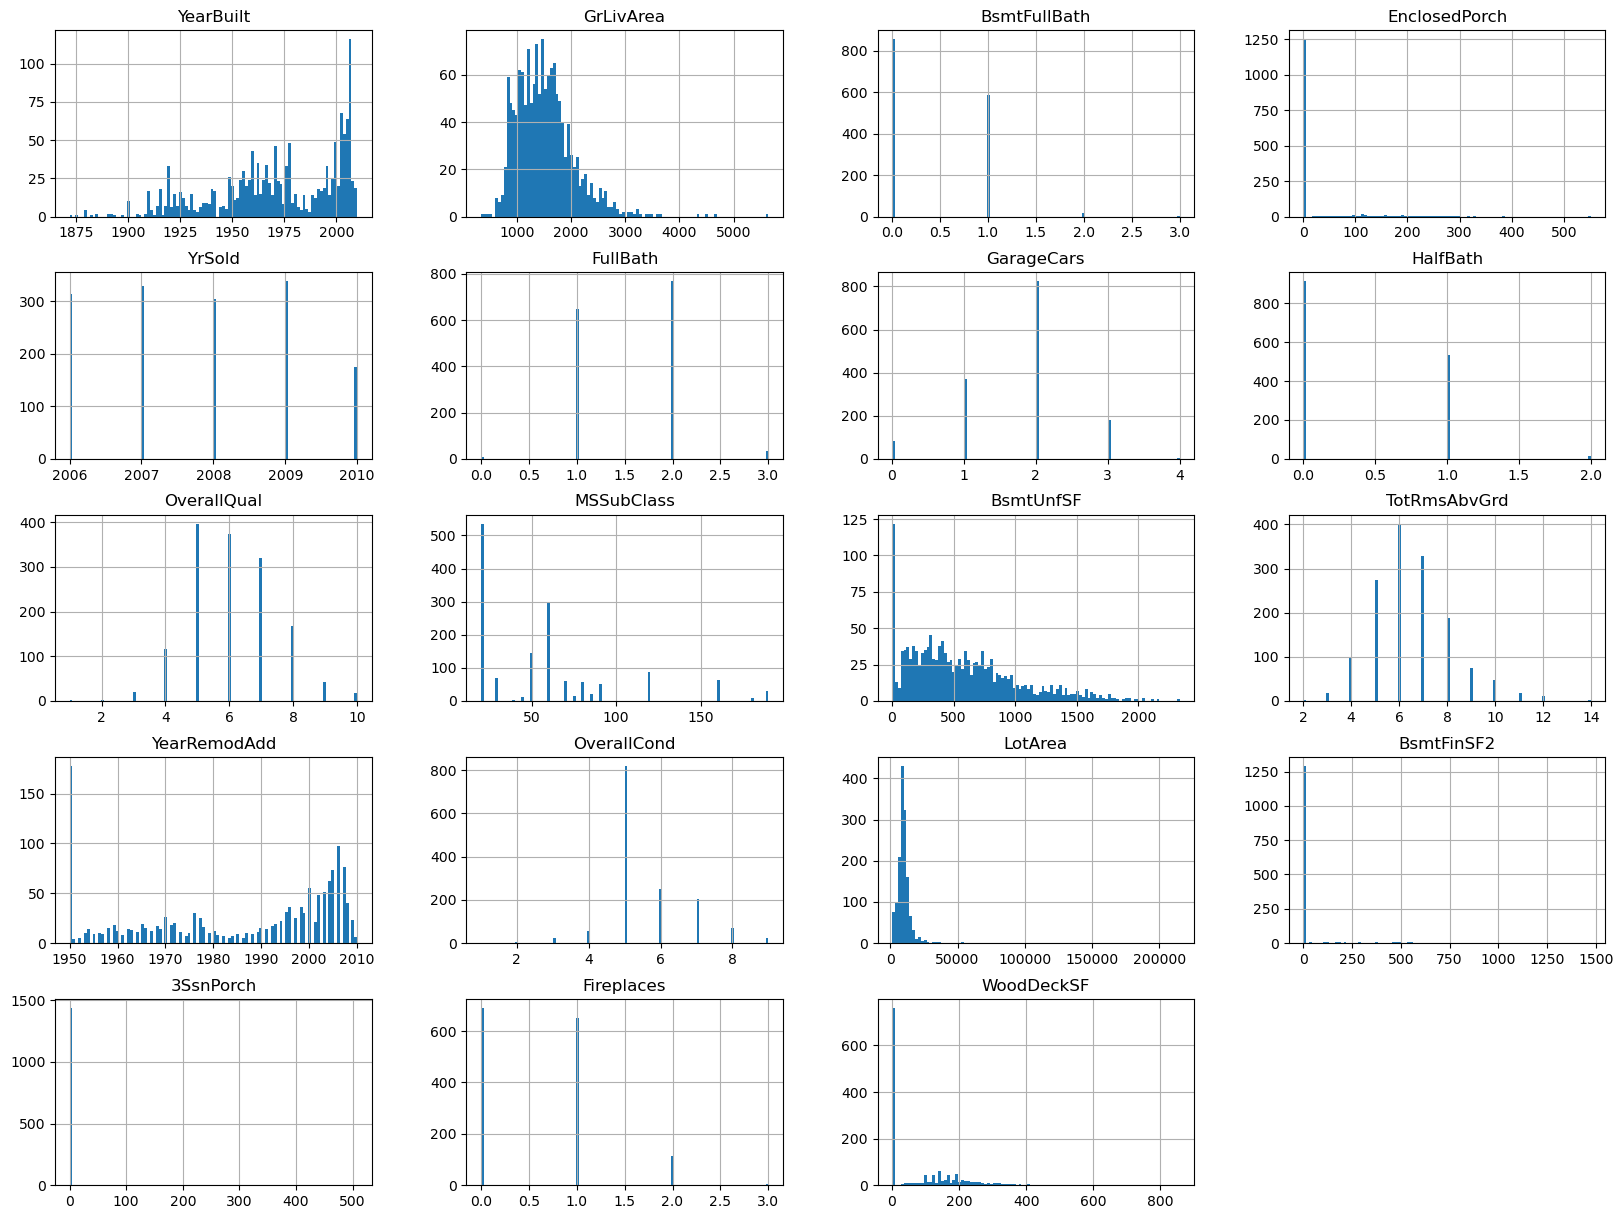

In [29]:
import matplotlib.pyplot as plt
train_data[num_cols[:19]].hist(bins=100,figsize=(20,15))

array([[<Axes: title={'center': 'ScreenPorch'}>,
        <Axes: title={'center': 'PoolArea'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'GarageYrBlt'}>],
       [<Axes: title={'center': 'MiscVal'}>,
        <Axes: title={'center': 'OpenPorchSF'}>,
        <Axes: title={'center': 'MoSold'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': 'SalePrice'}>,
        <Axes: title={'center': 'GarageArea'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>],
       [<Axes: title={'center': 'KitchenAbvGr'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'BedroomAbvGr'}>],
       [<Axes: title={'center': '2ndFlrSF'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

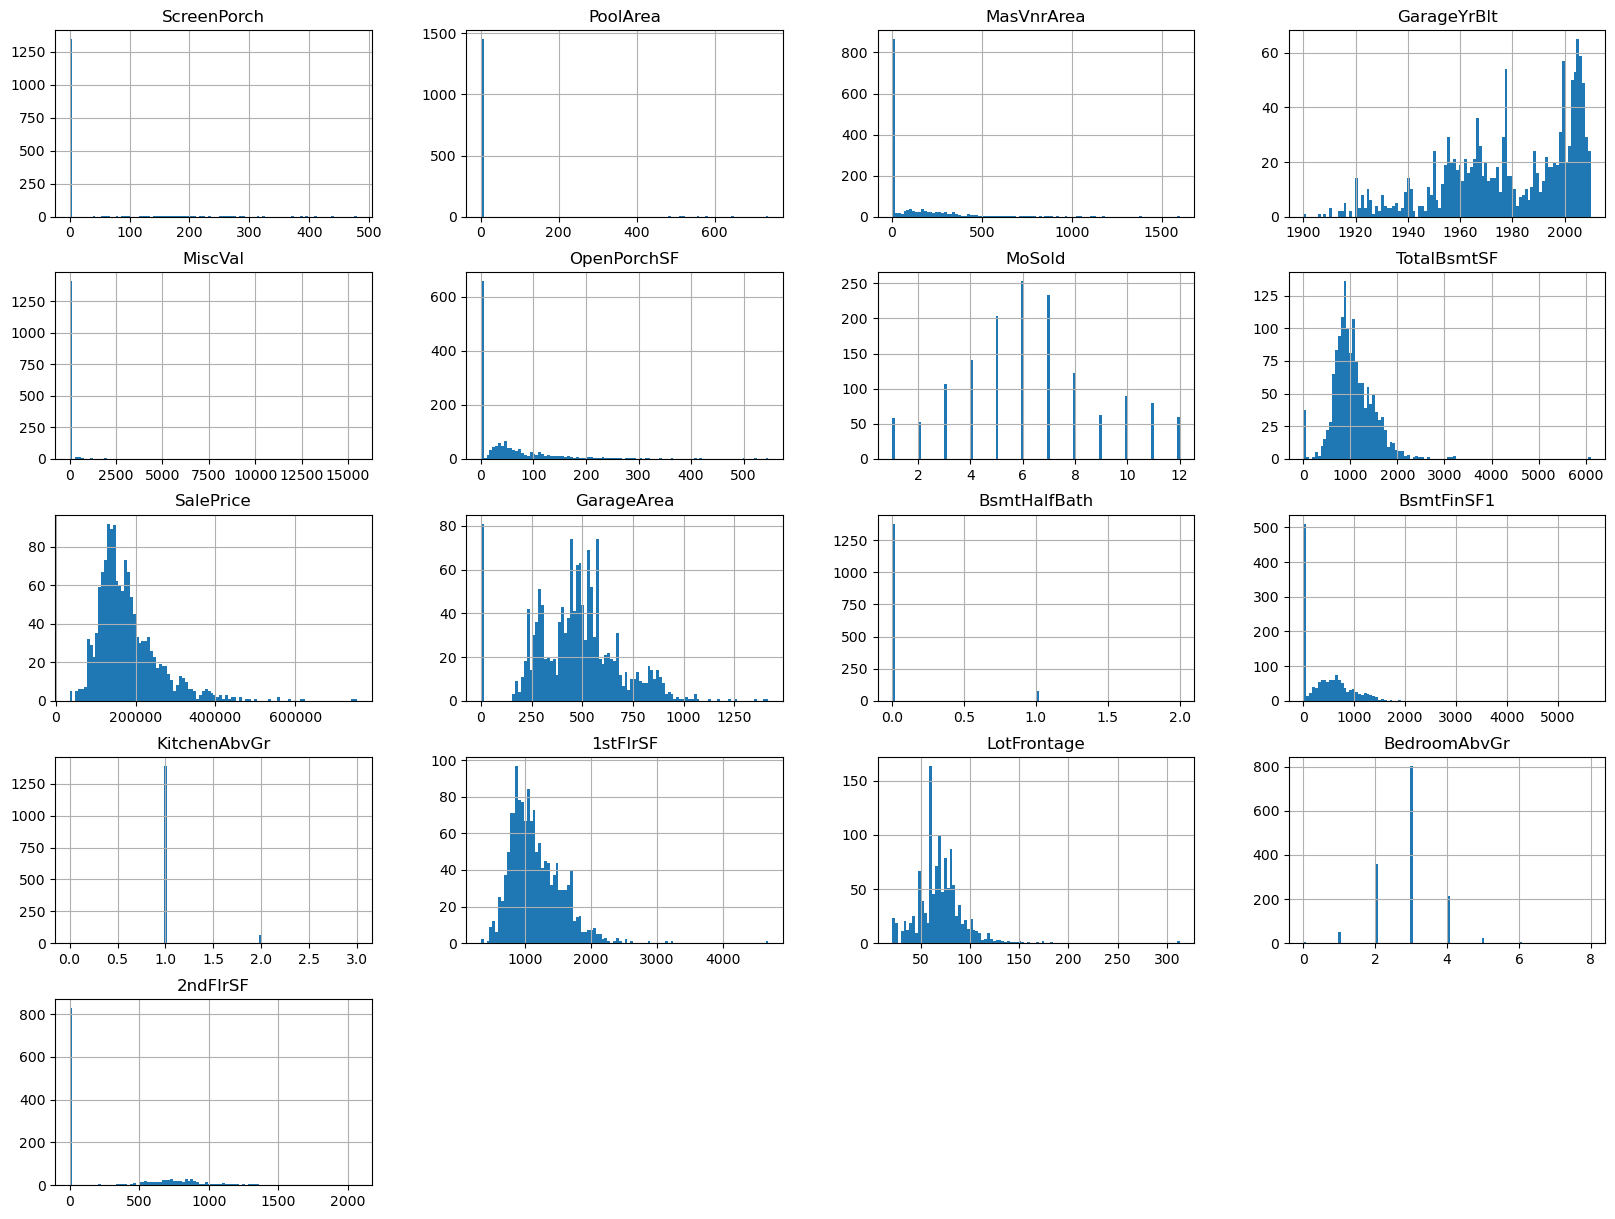

In [30]:
train_data[num_cols[20:]].hist(bins = 100, figsize = (20, 15))

In [31]:
corr_matrix = train_data[num_cols].corr()
corr_matrix

,YearBuilt,GrLivArea,BsmtFullBath,EnclosedPorch,YrSold,FullBath,GarageCars,HalfBath,OverallQual,MSSubClass,BsmtUnfSF,TotRmsAbvGrd,YearRemodAdd,OverallCond,LotArea,BsmtFinSF2,3SsnPorch,Fireplaces,WoodDeckSF,LowQualFinSF,ScreenPorch,PoolArea,MasVnrArea,GarageYrBlt,MiscVal,OpenPorchSF,MoSold,TotalBsmtSF,SalePrice,GarageArea,BsmtHalfBath,BsmtFinSF1,KitchenAbvGr,1stFlrSF,LotFrontage,BedroomAbvGr,2ndFlrSF
YearBuilt,1.000000,0.199010,0.187599,-0.387268,-0.013618,0.468271,0.537850,0.242656,0.572323,0.027850,0.149040,0.095589,0.592855,-0.375983,0.014228,-0.049107,0.031355,0.147716,0.224880,-0.183784,-0.050364,0.004950,0.315707,0.825667,-0.034383,0.188686,0.012398,0.391452,0.522897,0.478954,-0.038162,0.249503,-0.174800,0.281986,0.123349,-0.070651,0.010308
GrLivArea,0.199010,1.000000,0.034836,0.009113,-0.036526,0.630012,0.467247,0.415772,0.593007,0.074853,0.240257,0.825489,0.287389,-0.079686,0.263116,-0.009640,0.020643,0.461679,0.247433,0.134683,0.101510,0.170205,0.390857,0.231197,-0.002416,0.330224,0.050240,0.454868,0.708624,0.468997,-0.018918,0.208171,0.100063,0.566024,0.402797,0.521270,0.687501
BsmtFullBath,0.187599,0.034836,1.000000,-0.049911,0.067049,-0.064512,0.131881,-0.030905,0.111098,0.003491,-0.422900,-0.053275,0.119470,-0.054942,0.158155,0.158678,-0.000106,0.137928,0.175315,-0.047143,0.023148,0.067616,0.085310,0.124553,-0.023047,0.067341,-0.025361,0.307351,0.227122,0.179189,-0.147871,0.649212,-0.041503,0.244671,0.100949,-0.150673,-0.169494
EnclosedPorch,-0.387268,0.009113,-0.049911,1.000000,-0.009916,-0.115093,-0.151434,-0.095317,-0.113937,-0.012037,-0.002538,0.004151,-0.193919,0.070356,-0.018340,0.036543,-0.037305,-0.024822,-0.125989,0.061081,-0.082864,0.054203,-0.110204,-0.297003,0.018361,-0.093079,-0.028887,-0.095478,-0.128578,-0.121777,-0.008555,-0.102303,0.037312,-0.065292,0.010700,0.041570,0.061989
YrSold,-0.013618,-0.036526,0.067049,-0.009916,1.000000,-0.019669,-0.039117,-0.010269,-0.027347,-0.021407,-0.041258,-0.034516,0.035743,0.043950,-0.014261,0.031706,0.018645,-0.024096,0.022270,-0.028921,0.010694,-0.059689,-0.008201,-0.001014,0.004906,-0.057619,-0.145721,-0.014969,-0.028923,-0.027378,-0.046524,0.014359,0.031687,-0.013604,0.007450,-0.036014,-0.028700
FullBath,0.468271,0.630012,-0.064512,-0.115093,-0.019669,1.000000,0.469672,0.136381,0.550600,0.131608,0.288886,0.554784,0.439046,-0.194149,0.126031,-0.076444,0.035353,0.243671,0.187703,-0.000710,-0.008106,0.049604,0.276833,0.484557,-0.014290,0.259977,0.055872,0.323722,0.560664,0.405656,-0.054536,0.058543,0.133115,0.380637,0.198769,0.363252,0.421378
GarageCars,0.537850,0.467247,0.131881,-0.151434,-0.039117,0.469672,1.000000,0.219178,0.600671,-0.040110,0.214175,0.362289,0.420622,-0.185758,0.154871,-0.038264,0.035765,0.300789,0.226342,-0.094480,0.050494,0.020934,0.364204,0.588920,-0.043080,0.213569,0.040522,0.434585,0.640409,0.882475,-0.020891,0.224054,-0.050634,0.439317,0.285691,0.086106,0.183926
HalfBath,0.242656,0.415772,-0.030905,-0.095317,-0.010269,0.136381,0.219178,1.000000,0.273458,0.177354,-0.041118,0.343415,0.183331,-0.060769,0.014259,-0.032148,-0.004972,0.203649,0.108080,-0.027080,0.072426,0.022381,0.201444,0.196785,0.001290,0.199740,-0.009050,-0.048804,0.284108,0.163549,-0.012340,0.004262,-0.068263,-0.119916,0.053532,0.226651,0.609707
OverallQual,0.572323,0.593007,0.111098,-0.113937,-0.027347,0.550600,0.600671,0.273458,1.000000,0.032628,0.308159,0.427452,0.550684,-0.091932,0.105806,-0.059119,0.030371,0.396765,0.238923,-0.030429,0.064886,0.065166,0.411876,0.547766,-0.031406,0.308819,0.070815,0.537808,0.790982,0.562022,-0.040150,0.239666,-0.183882,0.476224,0.251646,0.101676,0.295493
MSSubClass,0.027850,0.074853,0.003491,-0.012037,-0.021407,0.131608,-0.040110,0.177354,0.032628,1.000000,-0.140759,0.040380,0.040581,-0.059316,-0.139781,-0.065649,-0.043825,-0.045569,-0.012579,0.046474,-0.026030,0.008283,0.022936,0.085072,-0.007683,-0.006100,-0.013585,-0.238518,-0.084284,-0.098672,-0.002333,-0.069836,0.281721,-0.251758,-0.386347,-0.023438,0.307886


<Axes: >

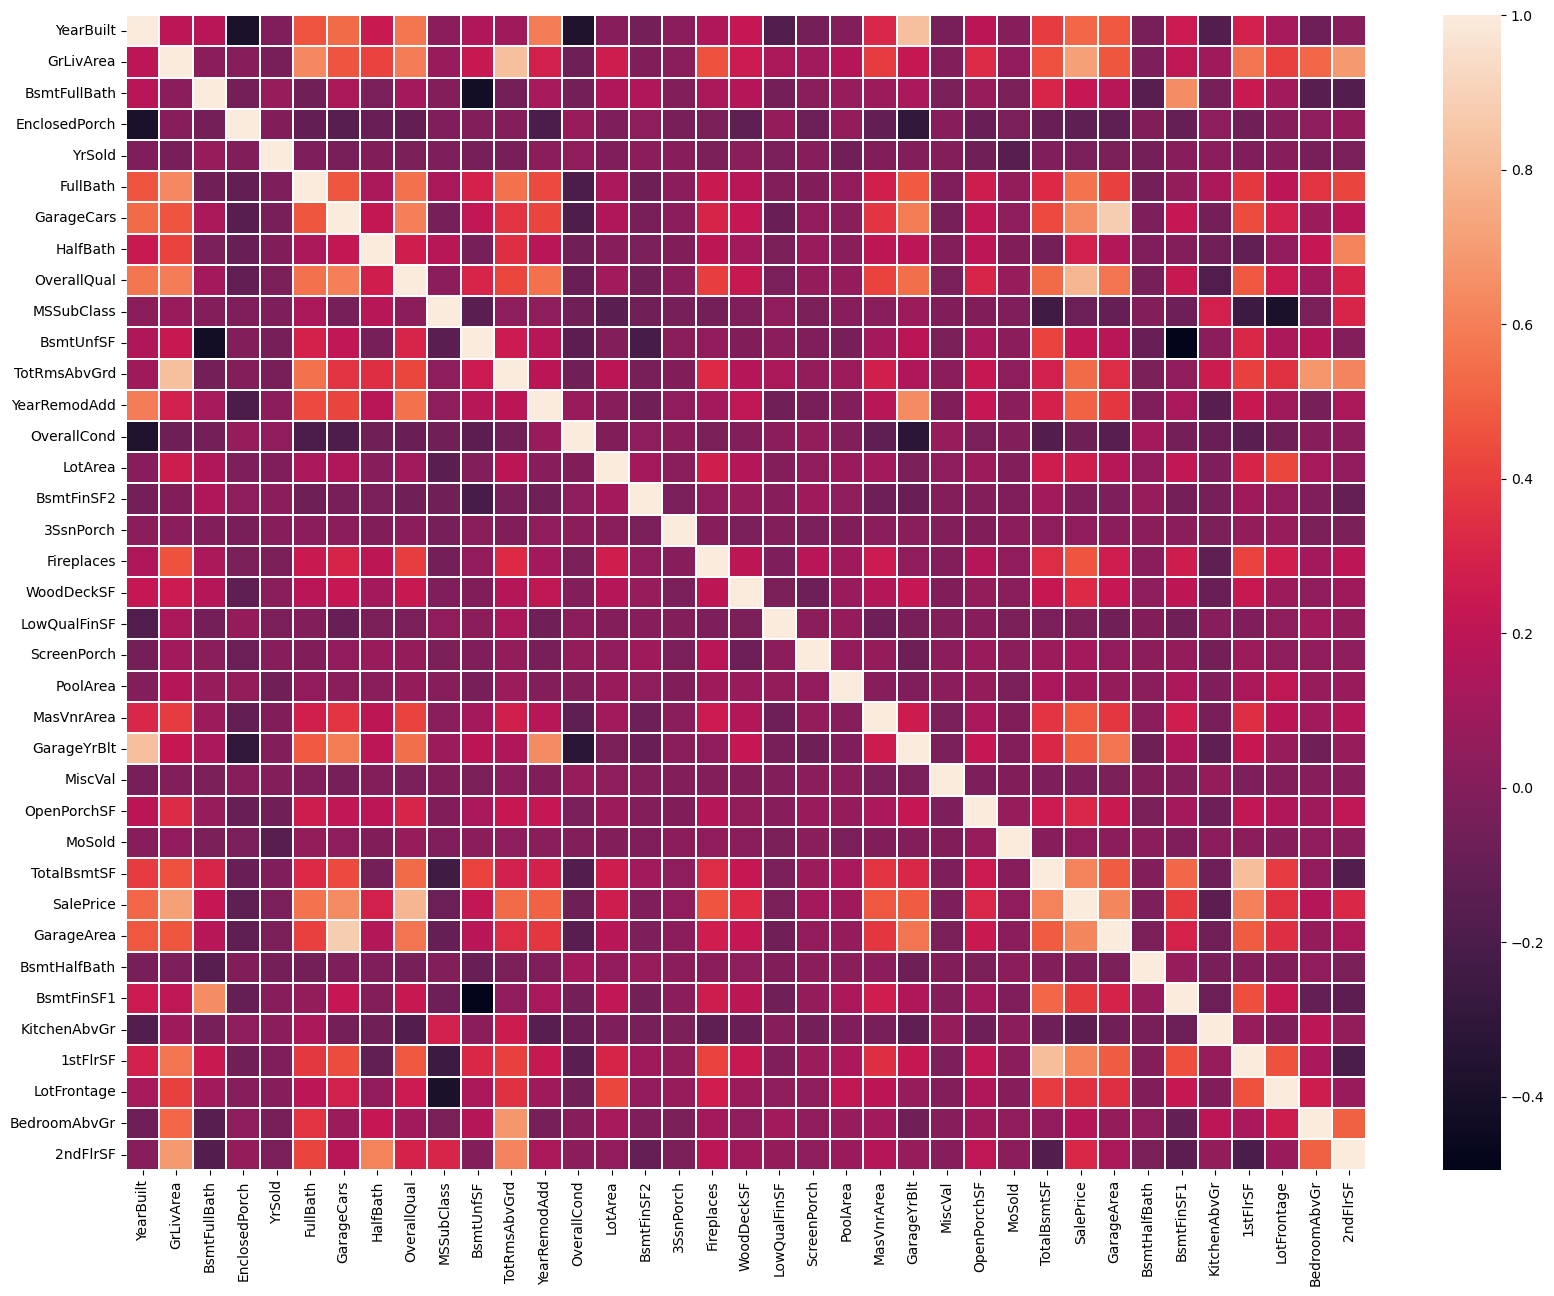

In [32]:
#heatmap
import seaborn as sns 
plt.subplots(figsize=(20,15))
sns.heatmap(corr_matrix,
           xticklabels = corr_matrix.columns.values,
           yticklabels = corr_matrix.columns.values,
           linewidth=0.1)

# Categorical Variables Visuals

In [33]:
df_list=[]
for cat_column in cat_cols:
    df_list.append(train_data.groupby([cat_column])['Id'].count().reset_index().rename(columns = {'Id' : 'count'}))
#     df_list.append(train_data[cat_column].value_counts().reset_index())
df_list

[  LandSlope  count
 0       Gtl   1382
 1       Mod     65
 2       Sev     13,
   BsmtExposure  count
 0           Av    221
 1           Gd    134
 2           Mn    114
 3           No    953,
   Condition1  count
 0     Artery     48
 1      Feedr     81
 2       Norm   1260
 3       PosA      8
 4       PosN     19
 5       RRAe     11
 6       RRAn     26
 7       RRNe      2
 8       RRNn      5,
   PoolQC  count
 0     Ex      2
 1     Fa      2
 2     Gd      3,
   FireplaceQu  count
 0          Ex     24
 1          Fa     33
 2          Gd    380
 3          Po     20
 4          TA    313,
   HeatingQC  count
 0        Ex    741
 1        Fa     49
 2        Gd    241
 3        Po      1
 4        TA    428,
    Exterior2nd  count
 0      AsbShng     20
 1      AsphShn      3
 2      Brk Cmn      7
 3      BrkFace     25
 4       CBlock      1
 5      CmentBd     60
 6      HdBoard    207
 7      ImStucc     10
 8      MetalSd    214
 9        Other      1
 10     Plywood 

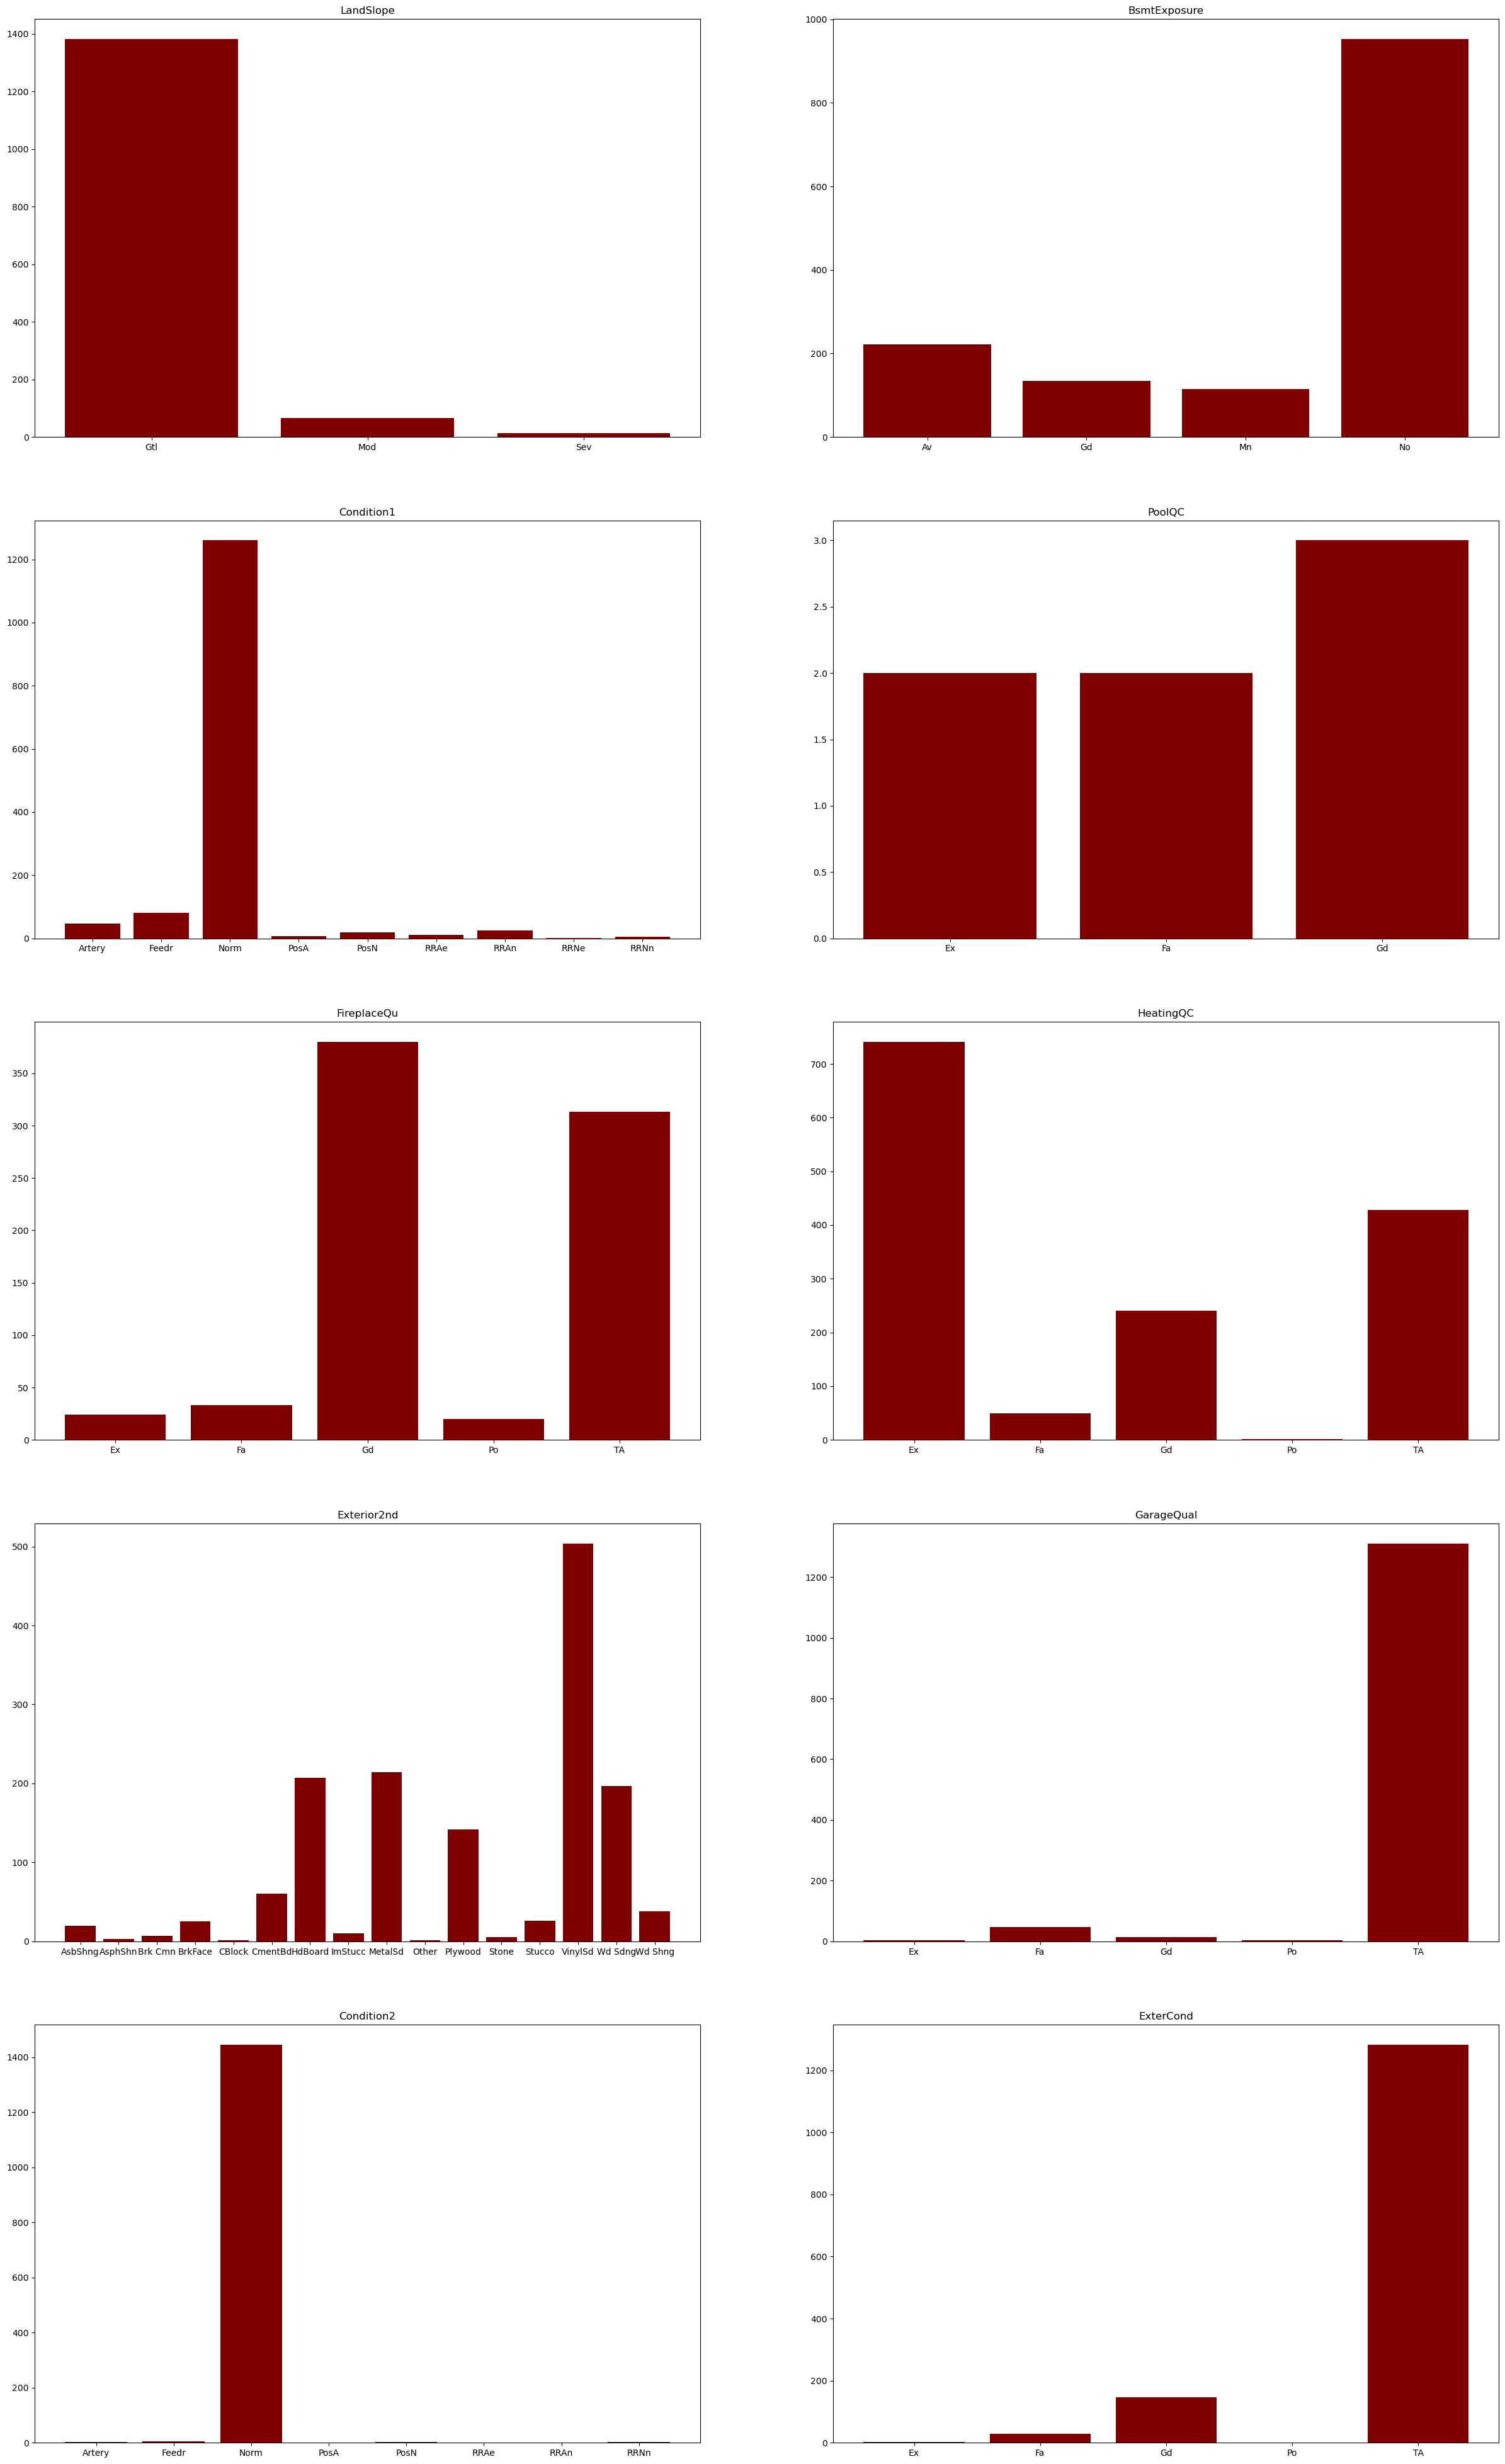

In [34]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(30, 50))
i=0
j=0
for df in df_list[0:10]:
    axes[i, j].bar(df.iloc[:, 0],df.iloc[:, 1], color ='maroon')
    axes[i, j].set_title(df.columns[0])
    if(j<1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

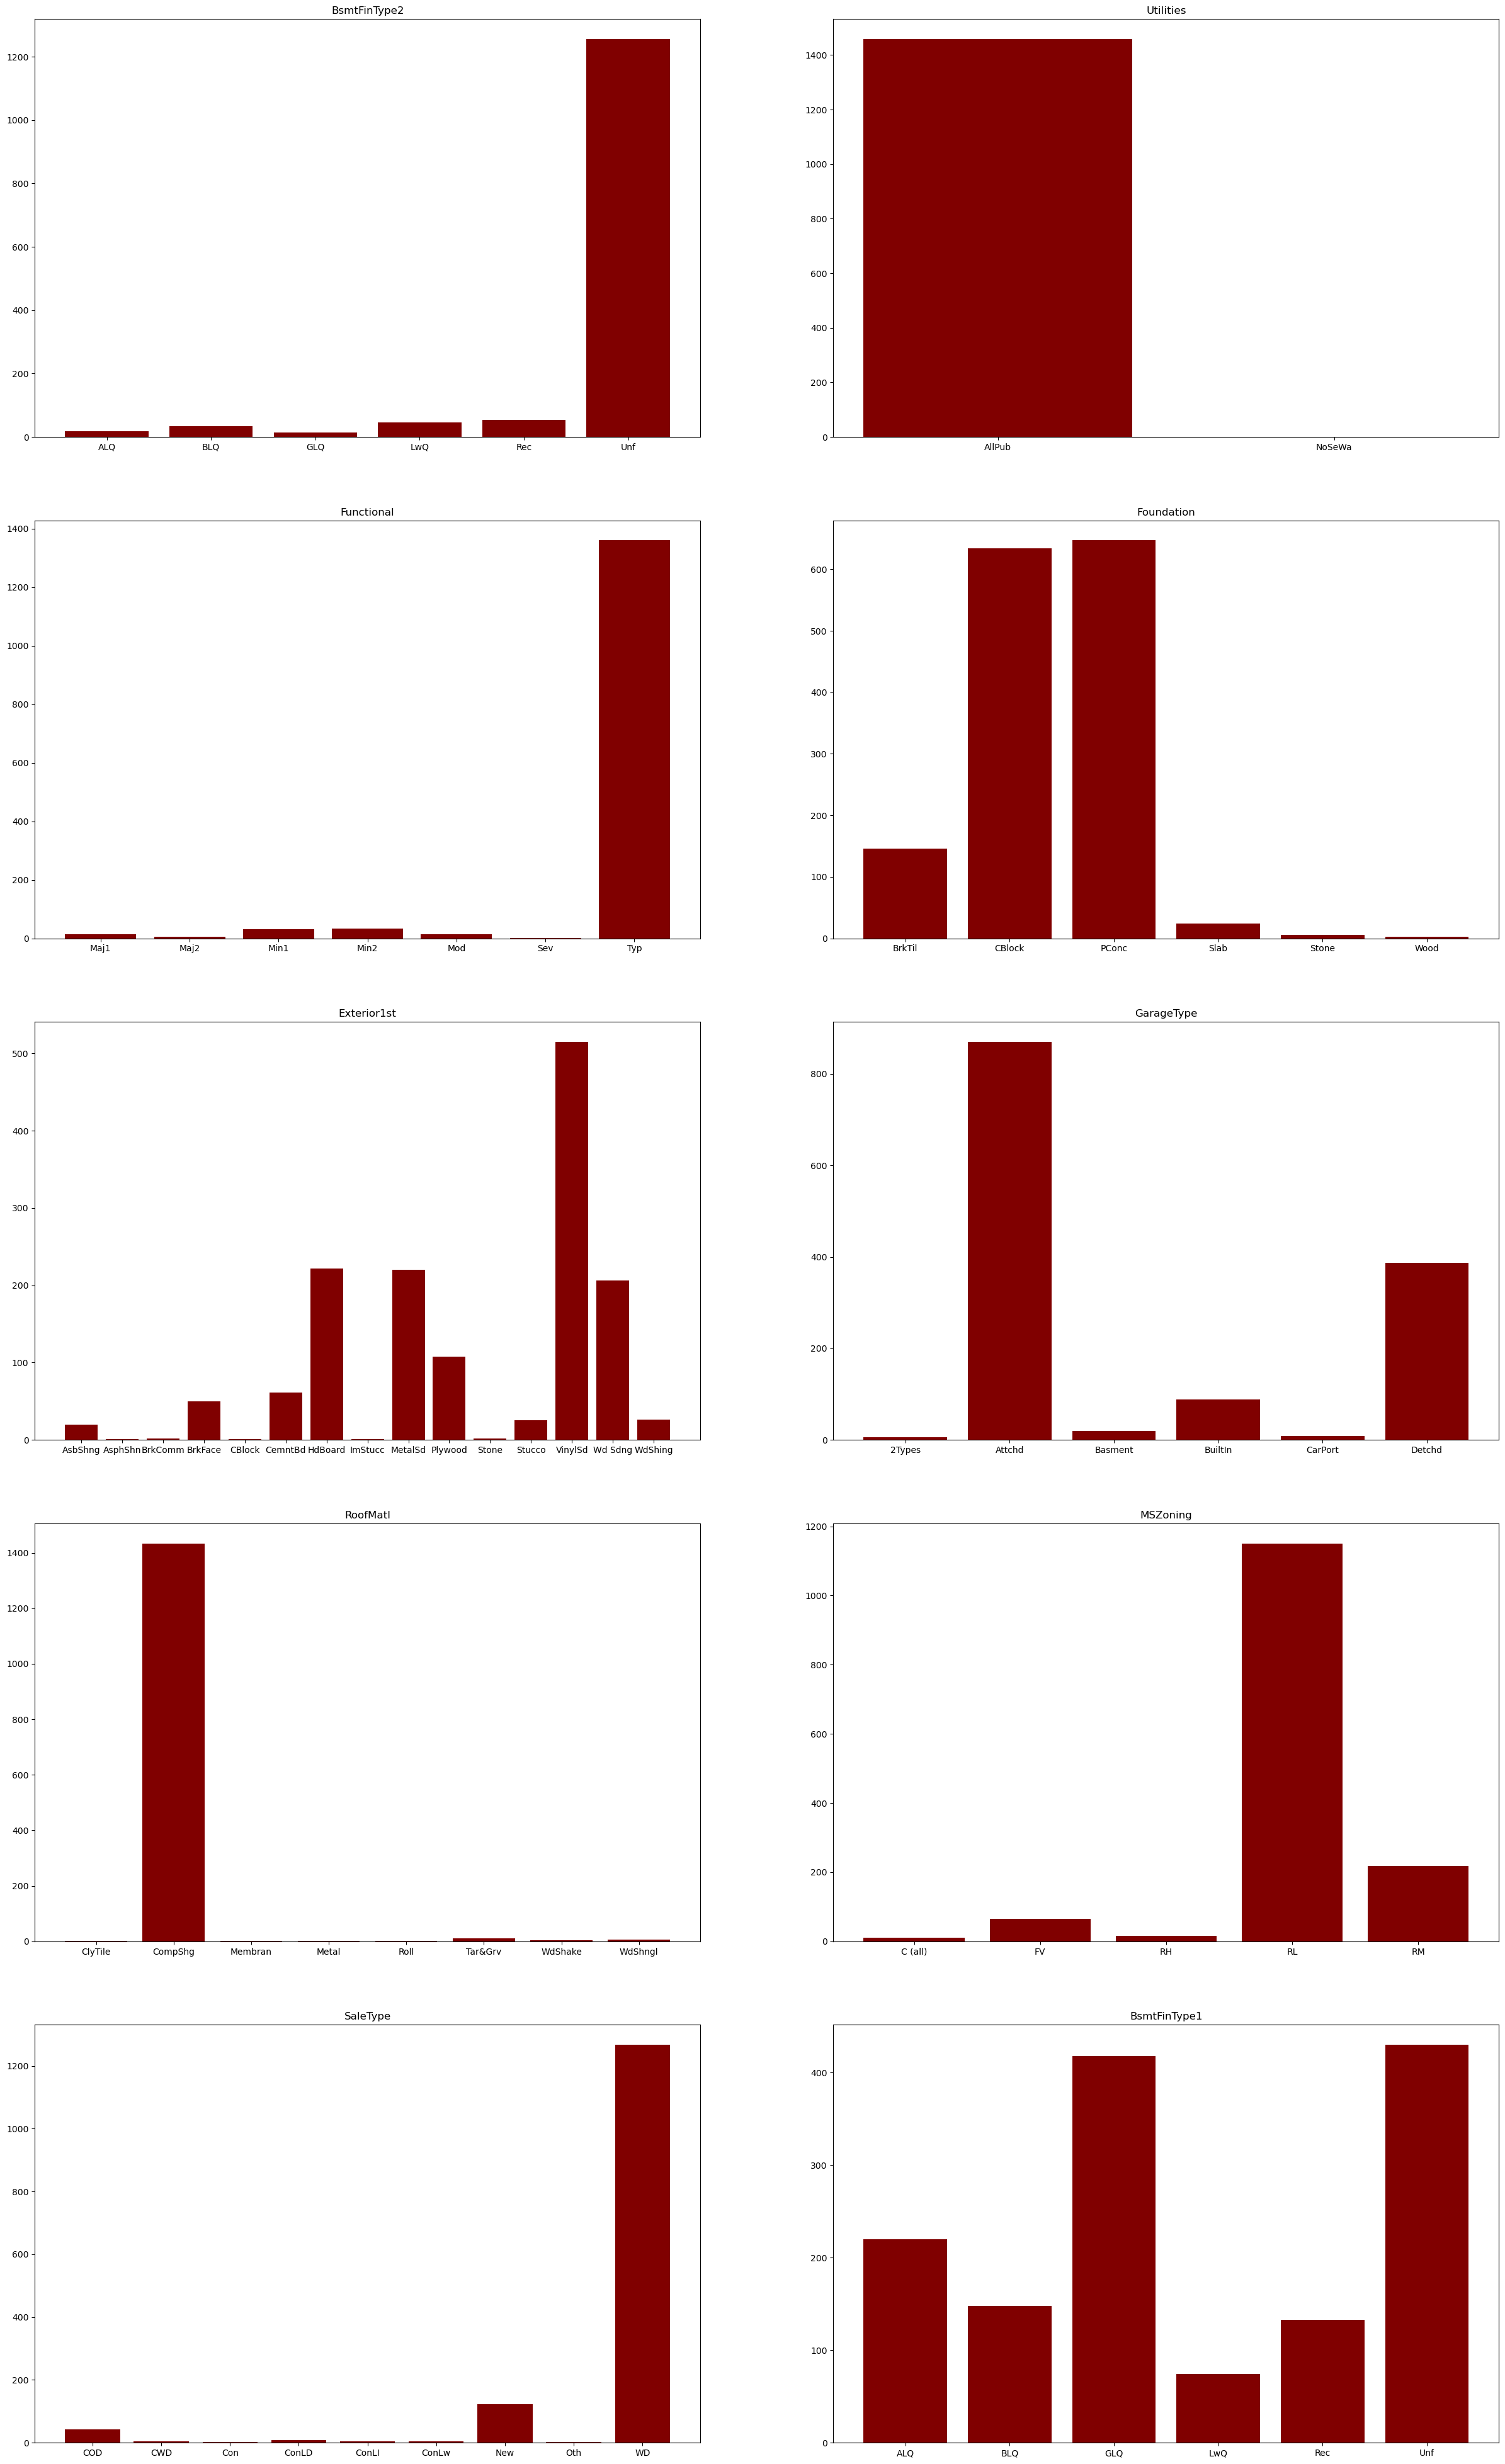

In [35]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(30, 50))
i=0
j=0
for df in df_list[10:20]:
    axes[i, j].bar(df.iloc[:, 0],df.iloc[:, 1], color ='maroon')
    axes[i, j].set_title(df.columns[0])
    if(j<1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

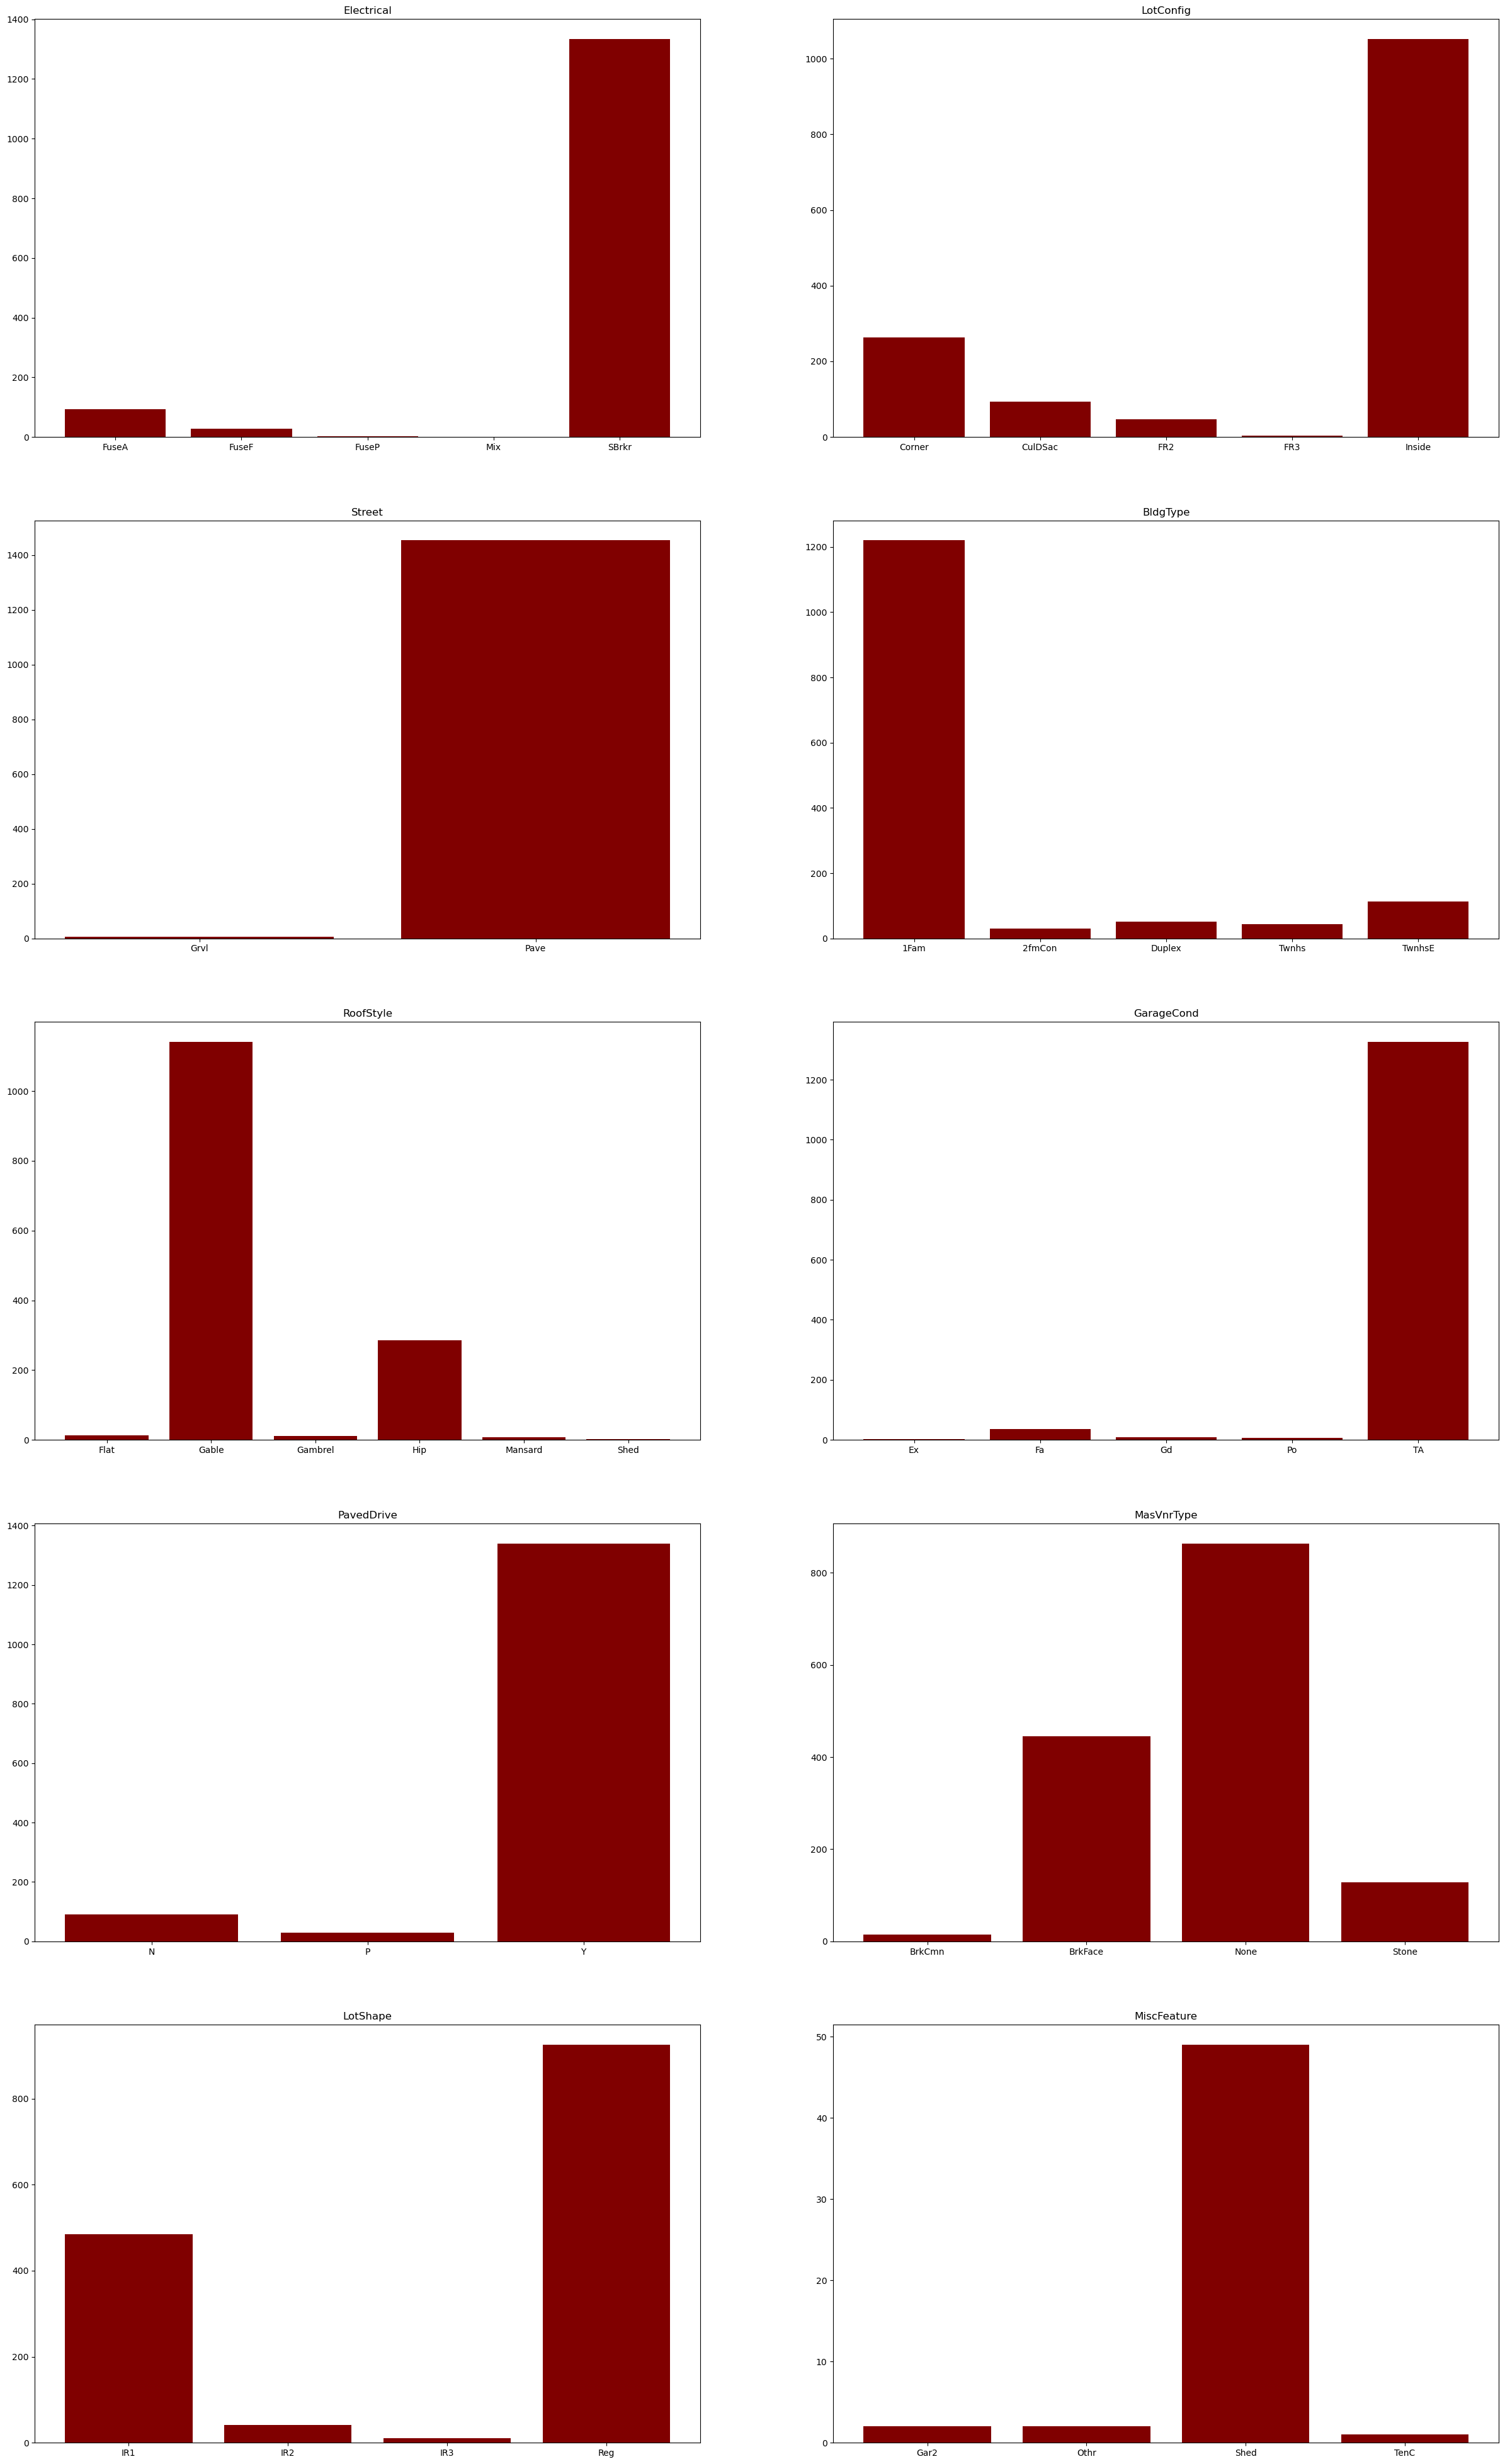

In [36]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(30, 50))
i=0
j=0
for df in df_list[20:30]:
    axes[i, j].bar(df.iloc[:, 0],df.iloc[:, 1], color ='maroon')
    axes[i, j].set_title(df.columns[0])
    if(j<1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

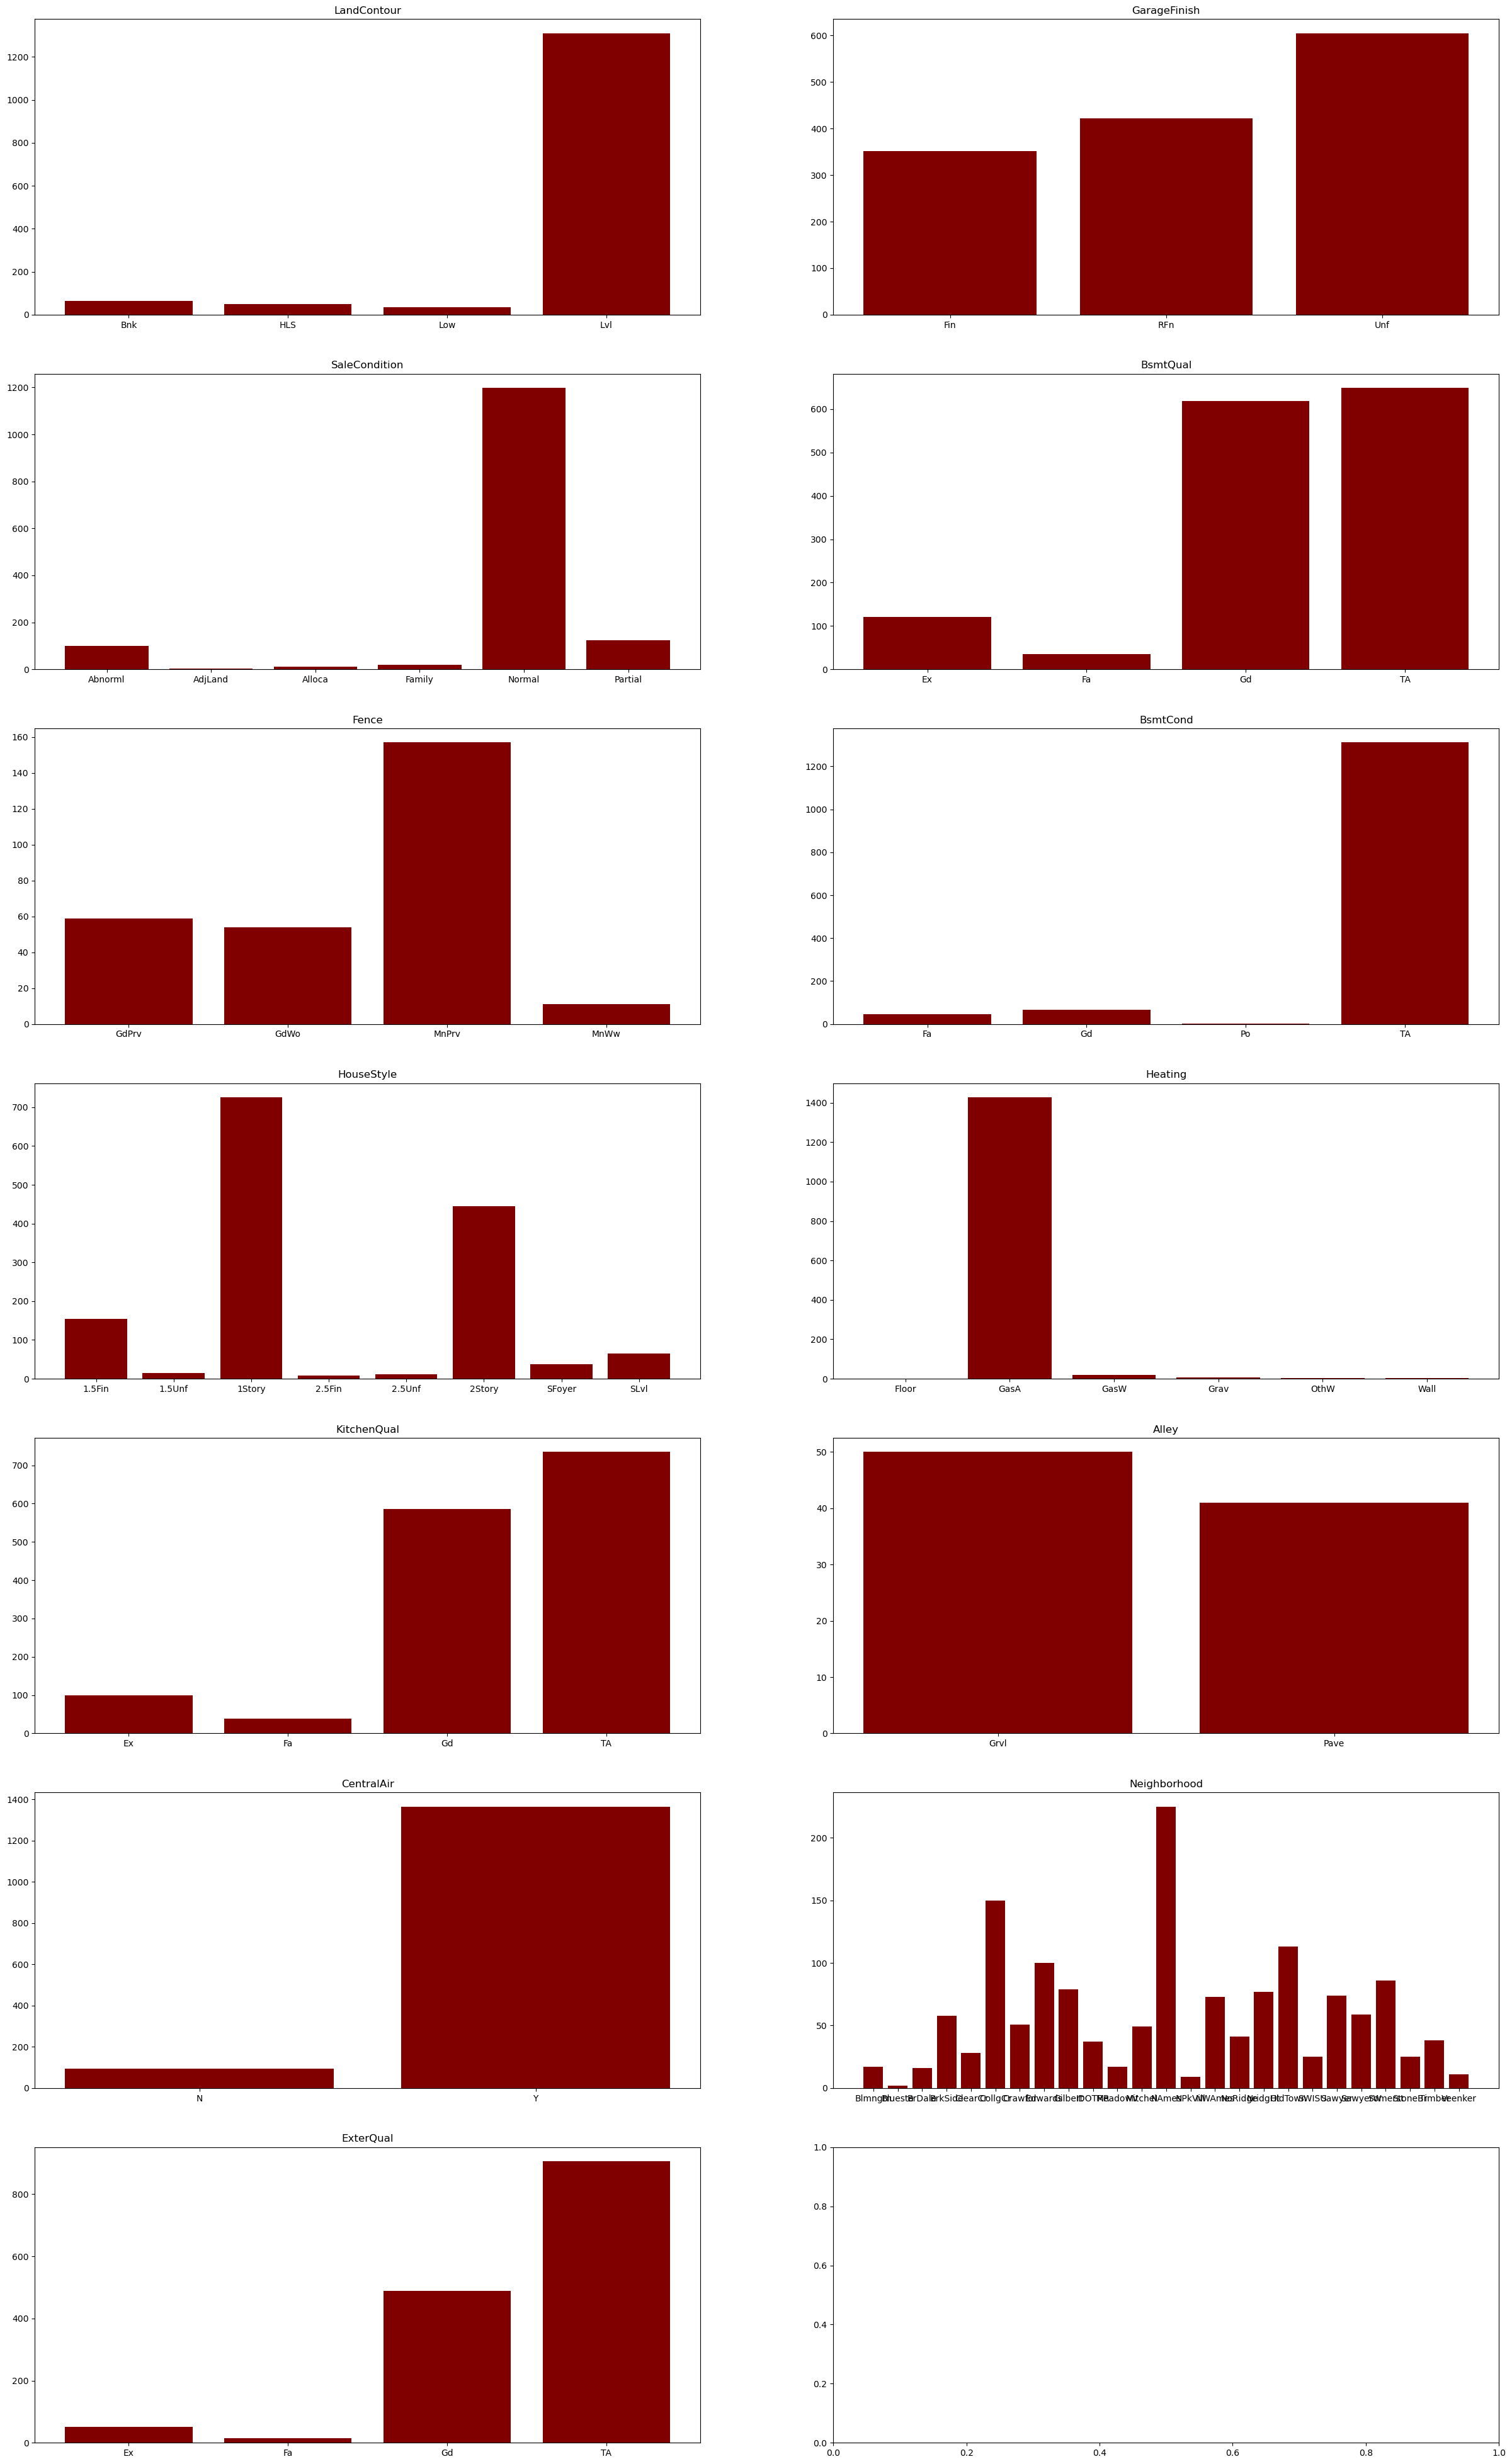

In [37]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(30, 50))
i=0
j=0
for df in df_list[30:]:
    axes[i, j].bar(df.iloc[:, 0],df.iloc[:, 1], color ='maroon')
    axes[i, j].set_title(df.columns[0])
    if(j<1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

# Preprocessing

## handling Null Values

In [38]:
train_data[num_cols].describe()

,YearBuilt,GrLivArea,BsmtFullBath,EnclosedPorch,YrSold,FullBath,GarageCars,HalfBath,OverallQual,MSSubClass,BsmtUnfSF,TotRmsAbvGrd,YearRemodAdd,OverallCond,LotArea,BsmtFinSF2,3SsnPorch,Fireplaces,WoodDeckSF,LowQualFinSF,ScreenPorch,PoolArea,MasVnrArea,GarageYrBlt,MiscVal,OpenPorchSF,MoSold,TotalBsmtSF,SalePrice,GarageArea,BsmtHalfBath,BsmtFinSF1,KitchenAbvGr,1stFlrSF,LotFrontage,BedroomAbvGr,2ndFlrSF
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000
mean,1971.267808,1515.463699,0.425342,21.954110,2007.815753,1.565068,1.767123,0.382877,6.099315,56.897260,567.240411,6.517808,1984.865753,5.575342,10516.828082,46.549315,3.409589,0.613014,94.244521,5.844521,15.060959,2.758904,103.685262,1978.506164,43.489041,46.660274,6.321918,1057.429452,180921.195890,472.980137,0.057534,443.639726,1.046575,1162.626712,70.049958,2.866438,346.992466
std,30.202904,525.480383,0.518911,61.119149,1.328095,0.550916,0.747315,0.502885,1.382997,42.300571,441.866955,1.625393,20.645407,1.112799,9981.264932,161.319273,29.317331,0.644666,125.338794,48.623081,55.757415,40.177307,181.066207,24.689725,496.123024,66.256028,2.703626,438.705324,79442.502883,213.804841,0.238753,456.098091,0.220338,386.587738,24.284752,0.815778,436.528436
min,1872.000000,334.000000,0.000000,0.000000,2006.000000,0.000000,0.000000,0.000000,1.000000,20.000000,0.000000,2.000000,1950.000000,1.000000,1300.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1900.000000,0.000000,0.000000,1.000000,0.000000,34900.000000,0.000000,0.000000,0.000000,0.000000,334.000000,21.000000,0.000000,0.000000
25%,1954.000000,1129.500000,0.000000,0.000000,2007.000000,1.000000,1.000000,0.000000,5.000000,20.000000,223.000000,5.000000,1967.000000,5.000000,7553.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1961.000000,0.000000,0.000000,5.000000,795.750000,129975.000000,334.500000,0.000000,0.000000,1.000000,882.000000,59.000000,2.000000,0.000000
50%,1973.000000,1464.000000,0.000000,0.000000,2008.000000,2.000000,2.000000,0.000000,6.000000,50.000000,477.500000,6.000000,1994.000000,5.000000,9478.500000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1980.000000,0.000000,25.000000,6.000000,991.500000,163000.000000,480.000000,0.000000,383.500000,1.000000,1087.000000,69.000000,3.000000,0.000000
75%,2000.000000,1776.750000,1.000000,0.000000,2009.000000,2.000000,2.000000,1.000000,7.000000,70.000000,808.000000,7.000000,2004.000000,6.000000,11601.500000,0.000000,0.000000,1.000000,168.000000,0.000000,0.000000,0.000000,166.000000,2002.000000,0.000000,68.000000,8.000000,1298.250000,214000.000000,576.000000,0.000000,712.250000,1.000000,1391.250000,80.000000,3.000000,728.000000
max,2010.000000,5642.000000,3.000000,552.000000,2010.000000,3.000000,4.000000,2.000000,10.000000,190.000000,2336.000000,14.000000,2010.000000,9.000000,215245.000000,1474.000000,508.000000,3.000000,857.000000,572.000000,480.000000,738.000000,1600.000000,2010.000000,15500.000000,547.000000,12.000000,6110.000000,755000.000000,1418.000000,2.000000,5644.000000,3.000000,4692.000000,313.000000,8.000000,2065.000000


In [39]:
nulls_df = train_data.isna().sum().reset_index().rename(columns = {0:"Nulls_Count"})
nulls_df[nulls_df['Nulls_Count']> 0]

,index,Nulls_Count
3,LotFrontage,259
6,Alley,1369
25,MasVnrType,8
26,MasVnrArea,8
30,BsmtQual,37
31,BsmtCond,37
32,BsmtExposure,38
33,BsmtFinType1,37
35,BsmtFinType2,38
42,Electrical,1


In [40]:
#drop columns with 60% of data NULL
train_data = train_data.drop(columns=['Alley','PoolQC','Fence','MiscFeature','FireplaceQu'])

#drop small number of rows that have small number of null values using dropna
train_data = train_data.dropna(axis = 0, subset = ['GarageYrBlt', 'MasVnrArea', 'Electrical', 
                                                   'GarageFinish', 'GarageQual', 'GarageCond', 'GarageType',
                                                   'BsmtFinType2', 'BsmtFinType1', 'BsmtExposure', 'BsmtCond', 
                                                   'BsmtQual', 'MasVnrType'])
# fill nulls with the mean 
train_data['LotFrontage']=train_data['LotFrontage'].fillna(train_data['LotFrontage'].mean())

In [41]:
nulls_df = train_data.isna().sum().reset_index().rename(columns = { 0 : "Nulls_Count"})
nulls_df[nulls_df['Nulls_Count'] > 0]

,index,Nulls_Count


### Dropping any column which has 80% of values with the same value 

In [43]:
def dropping_var_with_same_value(count_df,df):
    highest_freq_percentage = (count_df['count']/df.count()[0]).\
                    reset_index().sort_values(by=['count'],ascending=
                    False).iloc[0,1]
    if highest_freq_percentage>= 0.8:
        print('we will drop the column ',count_df.columns[0])
        df = df.drop(columns = [count_df.columns[0]])
    return df

In [45]:
for idx in range(len(df_list)):
  train_data = dropping_var_with_same_value(df_list[idx], train_data)

we will drop the column  LandSlope
we will drop the column  Condition1
we will drop the column  GarageQual
we will drop the column  Condition2
we will drop the column  ExterCond
we will drop the column  BsmtFinType2
we will drop the column  Utilities
we will drop the column  Functional
we will drop the column  RoofMatl
we will drop the column  MSZoning
we will drop the column  SaleType
we will drop the column  Electrical
we will drop the column  Street
we will drop the column  BldgType
we will drop the column  RoofStyle
we will drop the column  GarageCond
we will drop the column  PavedDrive
we will drop the column  LandContour
we will drop the column  SaleCondition
we will drop the column  BsmtCond
we will drop the column  Heating
we will drop the column  CentralAir
